# Практика по Логистической регрессии.
- Признаки (Features)
    1. `age` - Возраст участников в годах
    2. `physical_score` - Оценка физического здоровья, полученная в результате тестов.
- Целевая переменная (Target)
    1. `test_result` - 0 если аудио-тест НЕ пройдет; 1 если аудио-тест пройден.

In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [134]:
df = pd.read_csv('~//Documents//University//Анализ данных//'
                 '1. ML Course ipynb//DATA//hearing_test.csv')
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


## 1. Exploratory Data Analysis (EDA)

In [135]:
'Описательные статистики для данных'
df.describe()

,age,physical_score,test_result
count,5000.000000,5000.000000,5000.000000
mean,51.609000,32.760260,0.600000
std,11.287001,8.169802,0.489947
min,18.000000,-0.000000,0.000000
25%,43.000000,26.700000,0.000000
50%,51.000000,35.300000,1.000000
75%,60.000000,38.900000,1.000000
max,90.000000,50.000000,1.000000


In [136]:
'Сколько людей прошли тест, а сколько нет'
df['test_result'].value_counts()

test_result
1    3000
0    2000
Name: count, dtype: int64

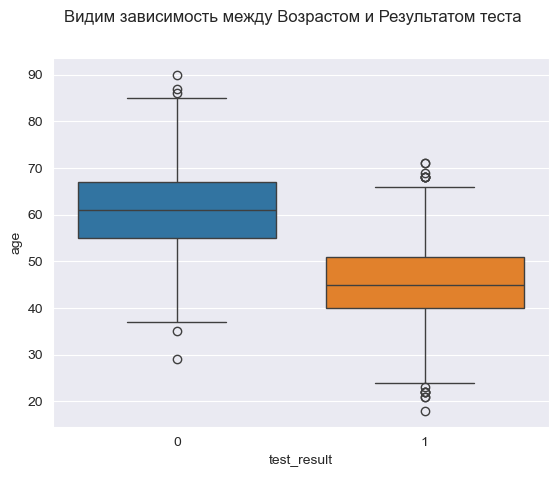

In [137]:
'Зависит ли Результат теста от Возраста?'
plt.suptitle('Видим зависимость между Возрастом и Результатом теста')
sns.boxplot(data=df, x='test_result', y='age', hue='test_result', legend=False);

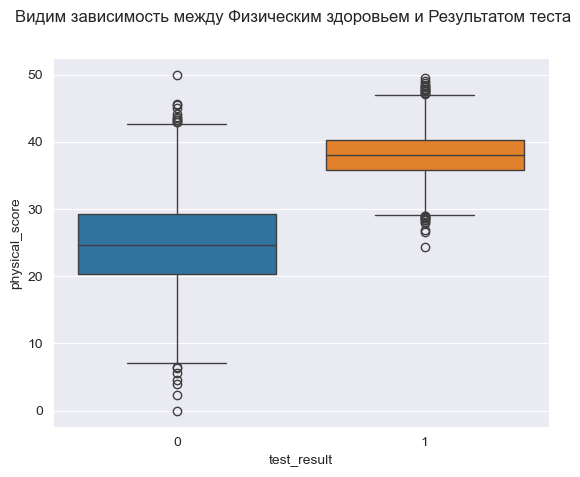

In [138]:
'Зависит ли Результат теста от Физического здоровья?'
plt.suptitle('Видим зависимость между Физическим здоровьем и Результатом теста')
sns.boxplot(data=df, x='test_result', y='physical_score', hue='test_result', legend=False);

<Axes: xlabel='physical_score', ylabel='Count'>

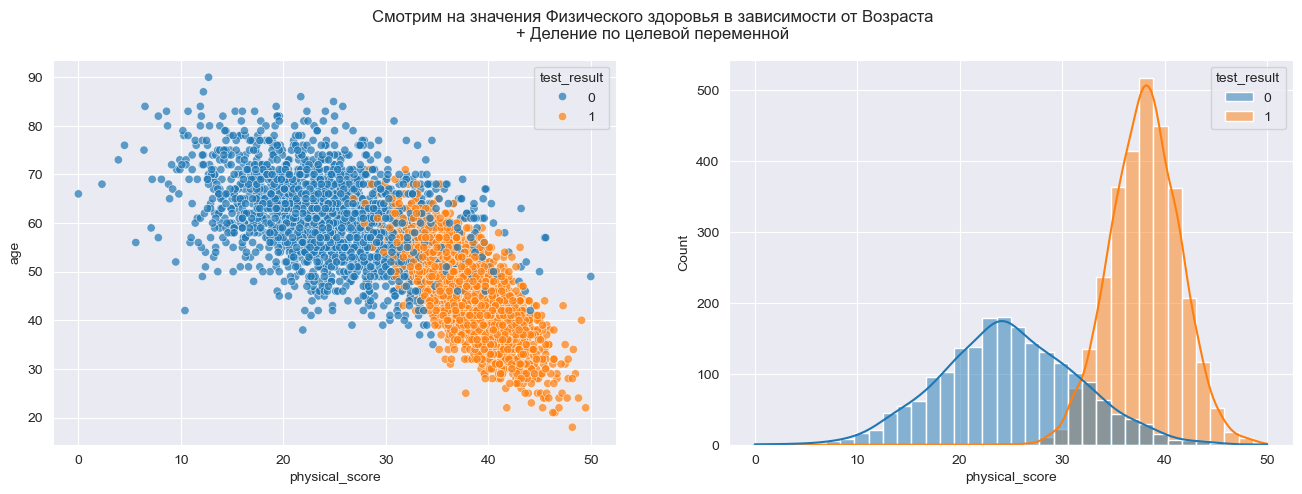

In [139]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Смотрим на значения Физического здоровья в зависимости от Возраста\n+ Деление по целевой переменной')
sns.scatterplot(data=df, x='physical_score', y='age', hue='test_result', alpha=0.7, ax=ax[0])
sns.histplot(data=df, x='physical_score', hue='test_result', ax=ax[1], kde=True)

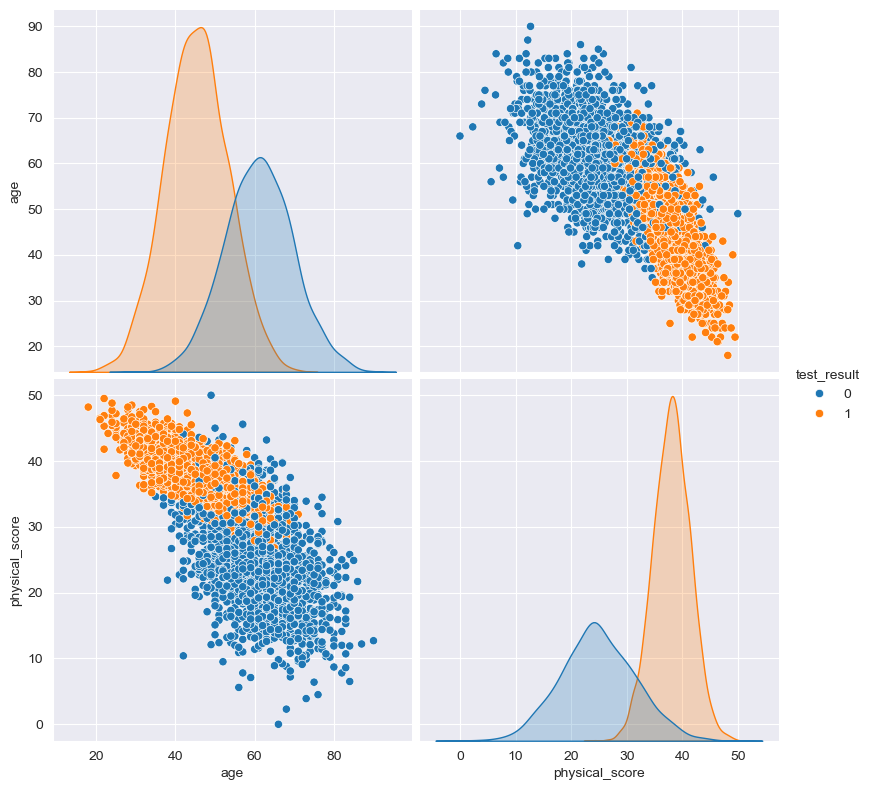

In [140]:
sns.pairplot(data=df, hue='test_result', height=4);

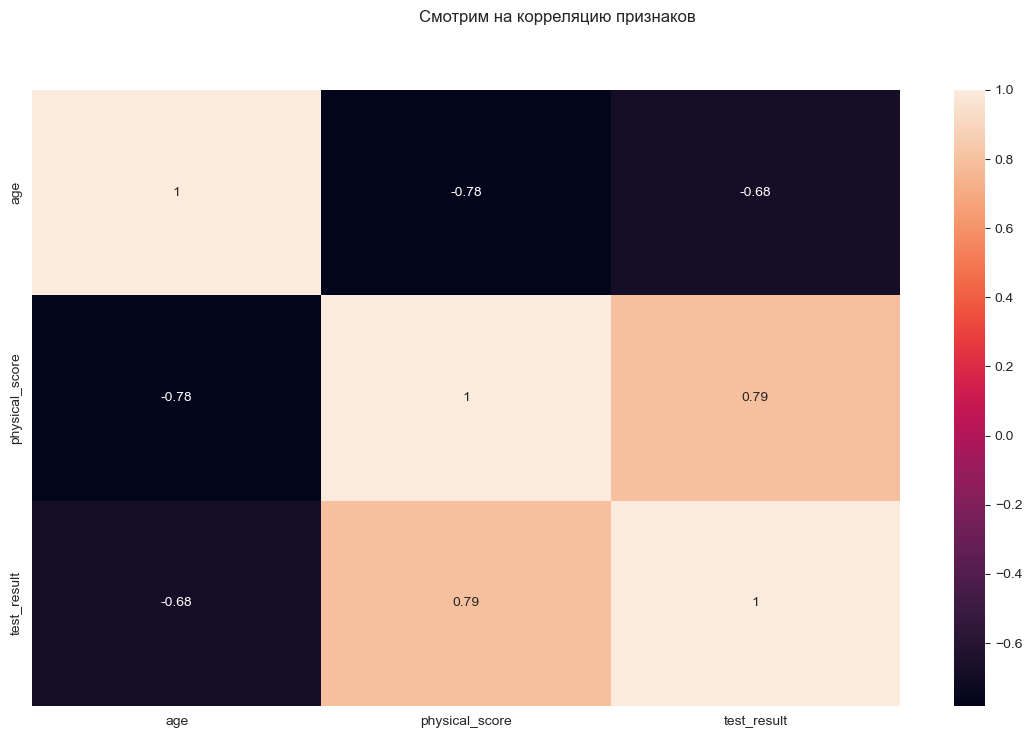

In [141]:
plt.figure(figsize=(14, 8))
plt.suptitle('Смотрим на корреляцию признаков')
sns.heatmap(df.corr(), annot=True);

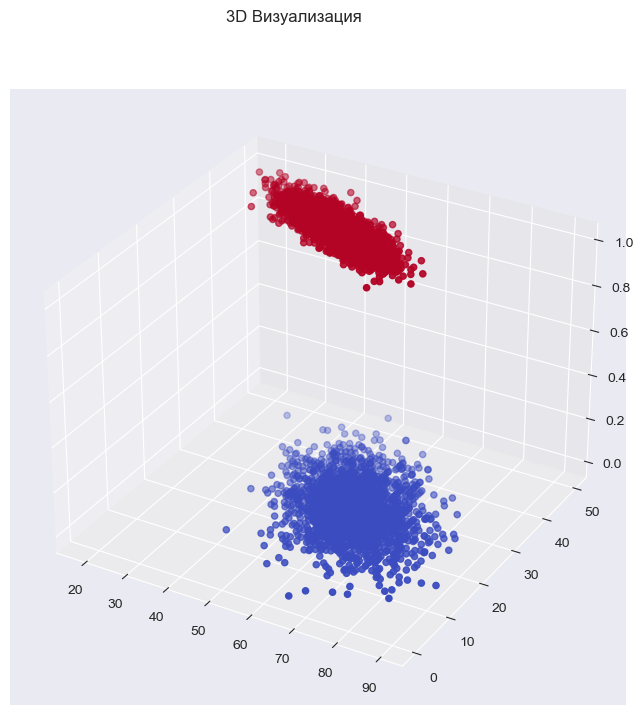

In [142]:
'Пробую визуализировать scatter в 3D'
fig = plt.figure(figsize=(19, 8))
ax = fig.add_subplot(projection='3d')
fig.suptitle('3D Визуализация')

ax.scatter(df['age'], df['physical_score'], df['test_result'], c=df['test_result'], cmap='coolwarm');

## 2. Создание и обучение модели

### Отделение признаков и целевой переменной

In [143]:
X = df.drop('test_result', axis=1)
y = df['test_result']
X

,age,physical_score
0,33.0,40.7
1,50.0,37.2
2,52.0,24.7
3,56.0,31.0
4,35.0,42.9
...,...,...
4995,73.0,3.9
4996,57.0,33.9
4997,49.0,34.5
4998,38.0,46.4


### Масштабирование признаков
#### Стандартизация или масштабирование
Многие модели МО (в частности Логистическая регрессия) чувствительна к масштабу признаков. Если один признак измеряется в годах (age: 18–90), а другой — в каких-то условных баллах (physical_score: 0–50), то:
- Признак с большими числами будет «доминировать» при вычислении расстояний и градиентов
- Градиентный спуск будет сходиться медленно и может «прыгать»
- Коэффициенты модели станут несопоставимыми для интерпретации

#### Что делает `StandardScaler`
Формула для каждого признака: $$x_{scaled} = \frac{x - \mu} {\sigma}$$
- $\mu$ - Среднее значение признака;
- $\sigma$ - Стандартное отклонение.

Таким образом, после преобразования каждый признак имеет среднее = 0 и стандартное отклонение = 1. Все признаки становятся сопоставимыми по масштабу.

In [144]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train) # Вычисляет среднее и стандартное отклонение по обучающей выборке
scaled_X_test = scaler.transform(X_test) # Применяет подсчитанные значения на тестовой выборке

### Создание модели

In [145]:
from sklearn.linear_model import LogisticRegression
help(LogisticRegression)

Help on class LogisticRegression in module sklearn.linear_model._logistic:

class LogisticRegression(sklearn.linear_model._base.LinearClassifierMixin, sklearn.linear_model._base.SparseCoefMixin, sklearn.base.BaseEstimator)
 |  LogisticRegression(penalty='l2', *, dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1, class_weight=None, random_state=None, solver='lbfgs', max_iter=100, multi_class='deprecated', verbose=0, warm_start=False, n_jobs=None, l1_ratio=None)
 |
 |  Logistic Regression (aka logit, MaxEnt) classifier.
 |
 |  In the multiclass case, the training algorithm uses the one-vs-rest (OvR)
 |  scheme if the 'multi_class' option is set to 'ovr', and uses the
 |  cross-entropy loss if the 'multi_class' option is set to 'multinomial'.
 |  (Currently the 'multinomial' option is supported only by the 'lbfgs',
 |  'sag', 'saga' and 'newton-cg' solvers.)
 |
 |  This class implements regularized logistic regression using the
 |  'liblinear' library, 'newton-cg', 's

In [146]:
log_model = LogisticRegression()
log_model.fit(scaled_X_train, y_train)

'Предсказанные значения целевой переменной'
y_predicted = log_model.predict(scaled_X_test)

'Предсказанный ЛОГАРИФМ вероятности'
y_log_proba_predicted = log_model.predict_log_proba(scaled_X_test)

'Предсказанная вероятность'
y_proba_predicted = log_model.predict_proba(scaled_X_test)


### Оценка работы модели
#### 1. Базовая оценка (Accuracy)
$$Accuracy = \frac{Правильные\ ответы} {Всего\ примеров}$$

#### 2. Матрица ошибок (Confusion Matrix)
Возвращает матрицу 2x2:
- TN - True Negative (Правильное предсказание, что тест НЕ пройден)
- FN - False Negative (Ошибочное предсказание, что тест НЕ пройден)
- FP - False Positive (Ошибочное предсказание, что тест пройден)
- TP - True Positive (Правильное предсказание, что тест пройден)

#### 3. Детальный отчёт (precision, recall, f1-score)
1. Precision - Из всех, кого назвали "пройдёт" - сколько действительно прошли. $$Precision = \frac{TP} {(TP + FP)}$$
2. Recall - Из всех, кто реально прошёл — сколько мы нашли. $$Recall = \frac{TP} {(TP + FN)}$$
3. F1-Score - Баланс между Precision и Recall. $$F1 = Гармоническое\ среднее$$

In [147]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

'Базовая точность'
accuracy = accuracy_score(y_test, y_predicted)
print(f'Базовая точность модели = {accuracy}')

Базовая точность модели = 0.93


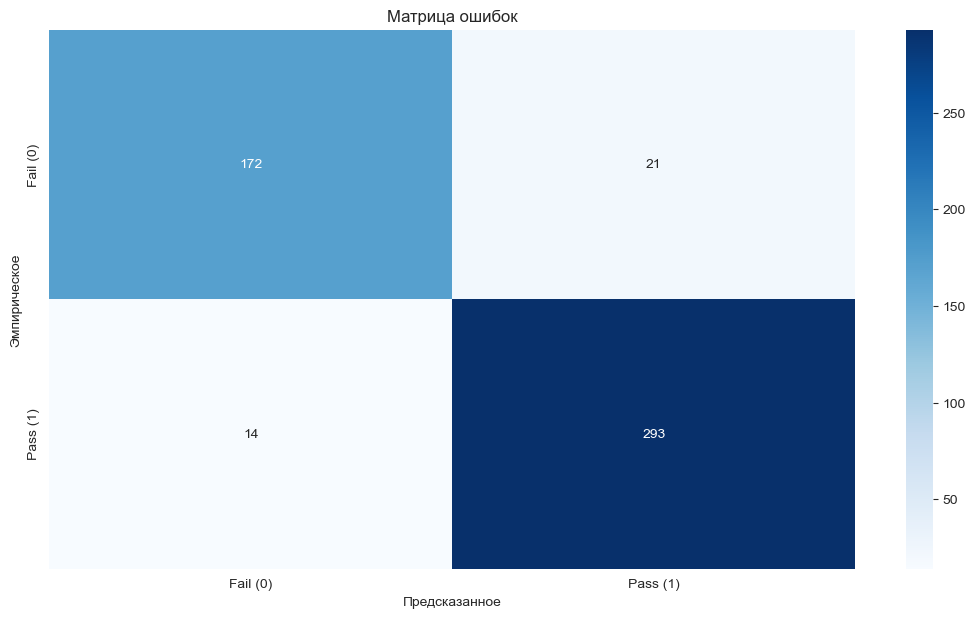

In [148]:
'Матрица ошибок'
cm = confusion_matrix(y_test, y_predicted)

plt.figure(figsize=(13, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail (0)', 'Pass (1)'],
            yticklabels=['Fail (0)', 'Pass (1)'])
plt.xlabel('Предсказанное')
plt.title('Матрица ошибок')
plt.ylabel('Эмпирическое');

In [149]:
cr = classification_report(y_test, y_predicted)
print(cr)

              precision    recall  f1-score   support

           0       0.92      0.89      0.91       193
           1       0.93      0.95      0.94       307

    accuracy                           0.93       500
   macro avg       0.93      0.92      0.93       500
weighted avg       0.93      0.93      0.93       500



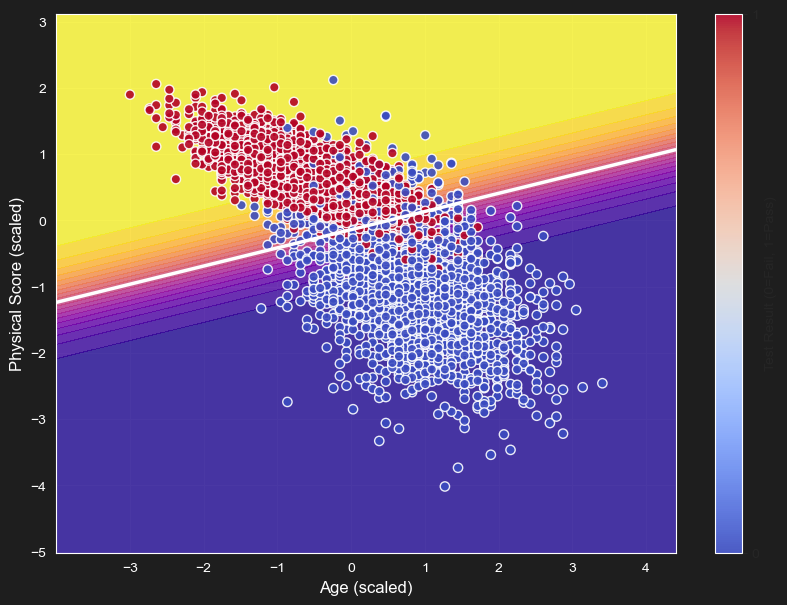

In [152]:
X_scaled_full = scaler.transform(X)

x_min, x_max = X_scaled_full[:, 0].min() - 1, X_scaled_full[:, 0].max() + 1
y_min, y_max = X_scaled_full[:, 1].min() - 1, X_scaled_full[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = log_model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7), facecolor='#1e1e1e')

plt.contourf(xx, yy, Z, levels=20, cmap='plasma', alpha=0.8)

plt.contour(xx, yy, Z, levels=[0.5], colors='white', linewidths=2.5)

scatter = plt.scatter(X_scaled_full[:, 0], X_scaled_full[:, 1],
                      c=y, cmap='coolwarm', edgecolors='white', alpha=0.9, s=45)

plt.colorbar(scatter, label='Test Result (0=Fail, 1=Pass)', ticks=[0, 1])
plt.xlabel('Age (scaled)', color='white', fontsize=12)
plt.ylabel('Physical Score (scaled)', color='white', fontsize=12)
plt.tick_params(colors='white')
plt.show()